In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from pandas.errors import EmptyDataError

In [2]:
climateVariables = [
'PAR_interior_(µmol_m_-2_s_-1)',
'Humedad_Relativa_interior_Alta_(%)',
'Humedad_Relativa_interior_Baja_(%)',
'Humedad_Relativa_interior_Centro_(%)',
'DPV_(kPa)',
'CO2_(ppm)',
'Radiación_Solar_Global_Interior_(W_m_-2)',
'Temperatura_Interior_Alta_(ºC)',
'Temperatura_Interior_Baja_(ºC)',
'Temperatura_Interior_Centro_(ºC)',
'Velocidad_viento_Interior_(m_s)',]

In [3]:
devicesVariables = [
'Recirculador',
'Calefactores',
'Fog',
'Pantalla_de_sombreo_cenital',
'Pantalla_de_sombreo_lateral_sur',
'Recirculador_centro',
'Ventana_cenital_este',
'Ventana_cenital_oeste',
'Ventana_lateral_norte',
'Ventana_lateral_oeste',
'Ventana_lateral_sur',
#'Luz_artificial_centro-este',
#'Luz_artificial_centro-oeste',
#'Luz_artificial_nor-este',
#'Luz_artificial_nor-oeste',
#'Luz_artificial_sur-este',
#'Luz_artificial_sur-oeste'
]

In [4]:
def readClimaticVariableData(path):
    df = pd.read_csv(path)
    df['_time'] = pd.to_datetime(df['_time'], format='mixed').dt.tz_localize(None).dt.strftime('%Y-%m-%d %H:%M:%S')
    df['_time'] = pd.to_datetime(df['_time'])
    df = df.set_index('_time').resample('min').mean().reset_index()
    return df

In [29]:
temp_centro = readClimaticVariableData('climate devices experiments data/Temperatura_Interior_Centro_(ºC)_0.csv')
temp_centro

,_time,_value
0,2026-08-03 00:00:00,26.825000
1,2026-08-03 00:01:00,26.813333
2,2026-08-03 00:02:00,26.787500
3,2026-08-03 00:03:00,26.777500
4,2026-08-03 00:04:00,26.760000
...,...,...
6639,2026-08-07 14:39:00,44.700000
6640,2026-08-07 14:40:00,44.855000
6641,2026-08-07 14:41:00,45.014000
6642,2026-08-07 14:42:00,45.217500


In [30]:
humedad_centro = readClimaticVariableData('climate devices experiments data/Humedad_Relativa_interior_Centro_(%)_0.csv')
humedad_centro

,_time,_value
0,2026-08-03 00:00:00,80.942500
1,2026-08-03 00:01:00,81.010000
2,2026-08-03 00:02:00,81.087500
3,2026-08-03 00:03:00,81.192500
4,2026-08-03 00:04:00,81.254000
...,...,...
6639,2026-08-07 14:39:00,26.703333
6640,2026-08-07 14:40:00,26.627500
6641,2026-08-07 14:41:00,26.396000
6642,2026-08-07 14:42:00,26.427500


In [31]:
for device in devicesVariables:
    print(f'Plotting {device} data...')
    try:
        device_data = pd.read_csv(f'climate devices experiments data/{device}_0.csv')
    except EmptyDataError as e:
      print(f"No data for device {device}: {e}")
      continue

    device_data['_time'] = pd.to_datetime(device_data['_time'], format='mixed', utc=True)
    # remove the timezone information from the _time column
    device_data['_time'] = device_data['_time'].dt.tz_localize(None)
    device_data['_time'] = device_data['_time'].dt.strftime('%Y-%m-%d %H:%M:%S')
    device_data['_time'] = pd.to_datetime(device_data['_time'])
    device_data['_value'] = device_data['_value'].clip(lower=0)  # set negative values to 0

    if device_data['_value'].max() == 1:
        device_data['_value'] = device_data['_value'] * 100  # convert to percentage

    # drop duplicated rows based on the _time column
    device_data = device_data.drop_duplicates(subset=['_time'])

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=device_data['_time'], y=device_data['_value'], mode='lines', name=device))
    
    fig.add_trace(go.Scatter(x=temp_centro['_time'], y=temp_centro['_value'], mode='lines', name='Temp Centro'))
    fig.add_trace(go.Scatter(x=humedad_centro['_time'], y=humedad_centro['_value'], mode='lines', name='Humedad Centro'))
    fig.show()

Plotting Recirculador data...


Plotting Calefactores data...


Plotting Fog data...


Plotting Pantalla_de_sombreo_cenital data...


Plotting Pantalla_de_sombreo_lateral_sur data...
No data for device Pantalla_de_sombreo_lateral_sur: No columns to parse from file
Plotting Recirculador_centro data...


...

Plotting Ventana_cenital_oeste data...


Plotting Ventana_lateral_norte data...


Plotting Ventana_lateral_oeste data...


Plotting Ventana_lateral_sur data...


Plotting Luz_artificial_centro-este data...
No data for device Luz_artificial_centro-este: No columns to parse from file
Plotting Luz_artificial_centro-oeste data...
No data for device Luz_artificial_centro-oeste: No columns to parse from file
Plotting Luz_artificial_nor-este data...
No data for device Luz_artificial_nor-este: No columns to parse from file
Plotting Luz_artificial_nor-oeste data...
No data for device Luz_artificial_nor-oeste: No columns to parse from file
Plotting Luz_artificial_sur-este data...
No data for device Luz_artificial_sur-este: No columns to parse from file
Plotting Luz_artificial_sur-oeste data...
No data for device Luz_artificial_sur-oeste: No columns to parse from file


## Same comparison, plotted with matplotlib

Plotting Recirculador data...


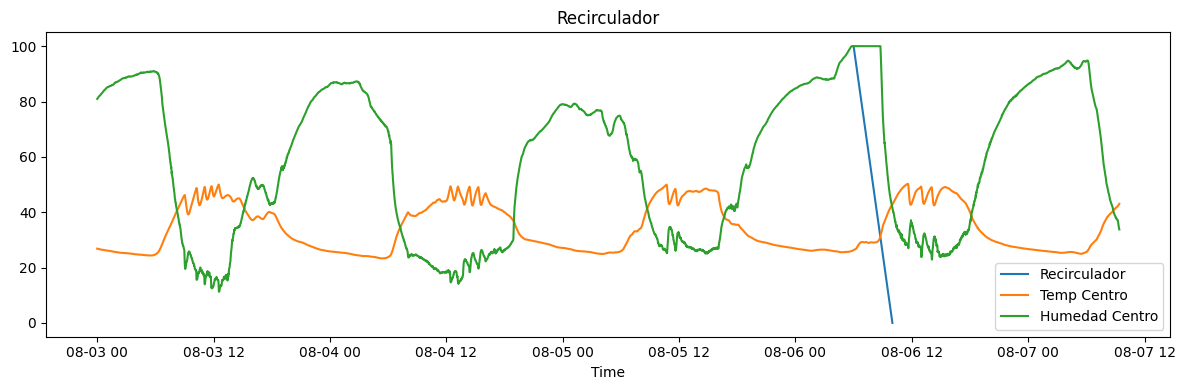

Plotting Calefactores data...


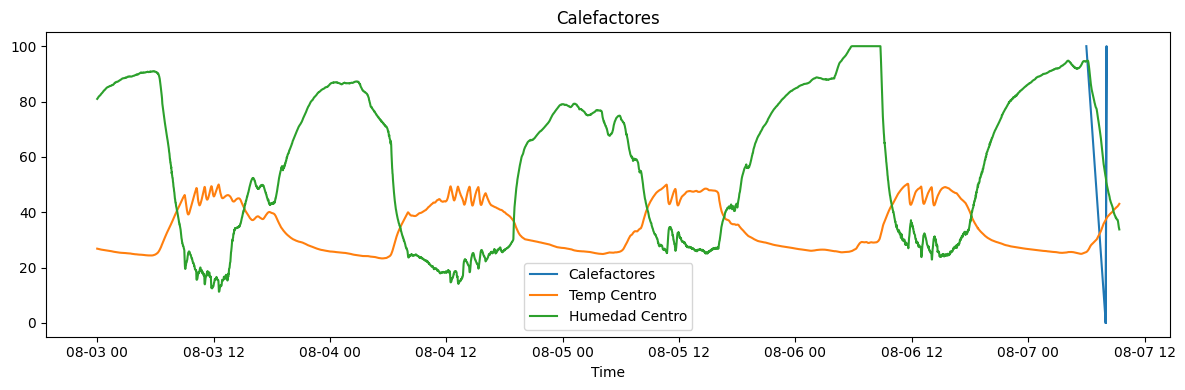

Plotting Fog data...


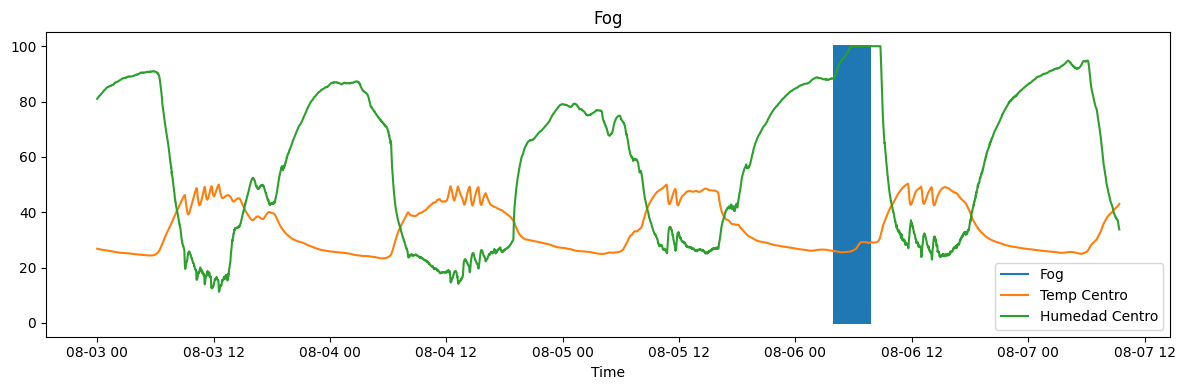

Plotting Pantalla_de_sombreo_cenital data...


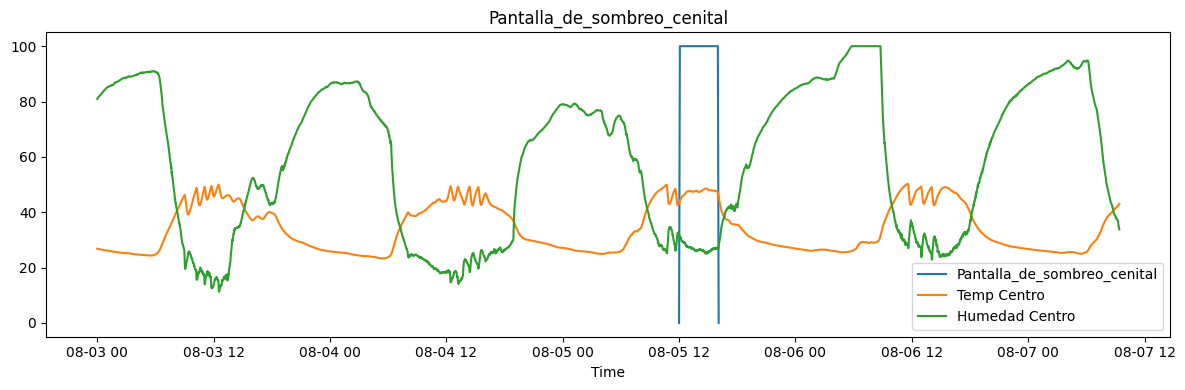

Plotting Pantalla_de_sombreo_lateral_sur data...
No data for device Pantalla_de_sombreo_lateral_sur: No columns to parse from file
Plotting Recirculador_centro data...


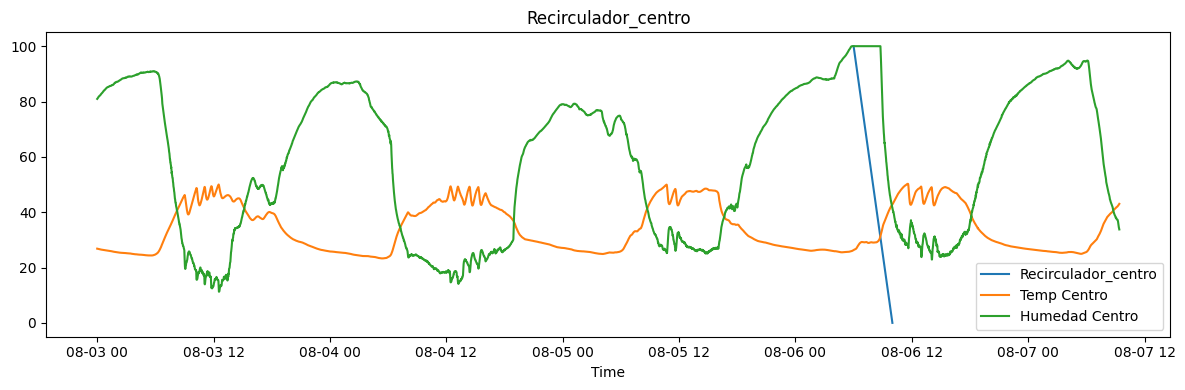

Plotting Ventana_cenital_este data...


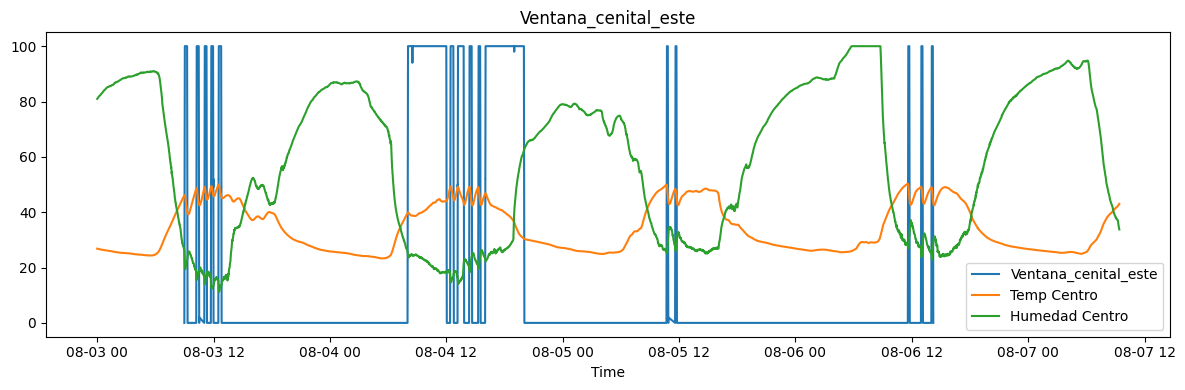

Plotting Ventana_cenital_oeste data...


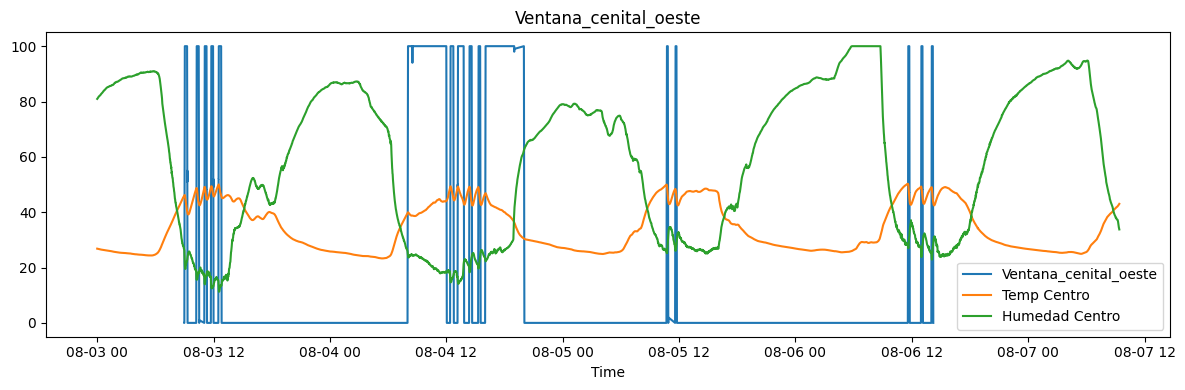

Plotting Ventana_lateral_norte data...


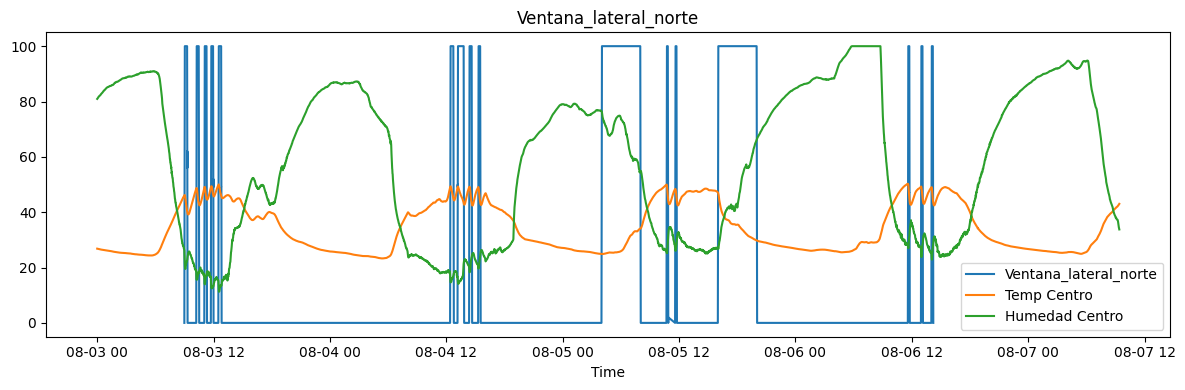

Plotting Ventana_lateral_oeste data...


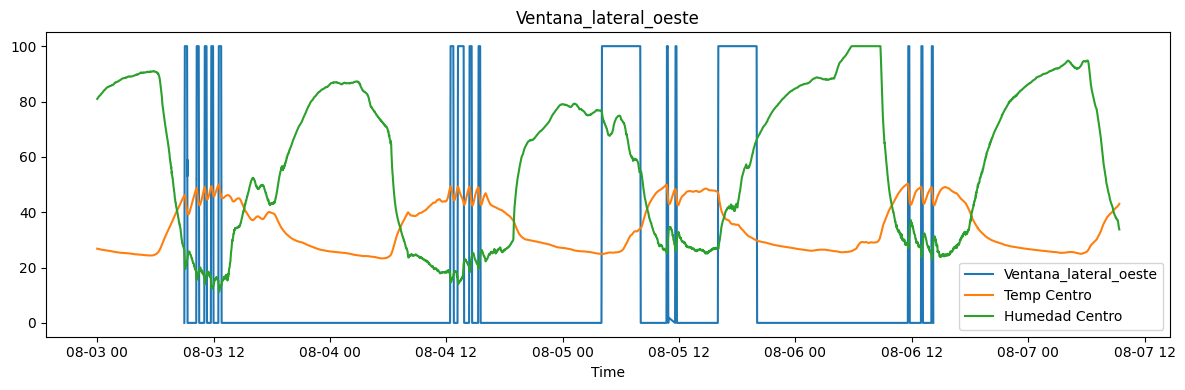

Plotting Ventana_lateral_sur data...


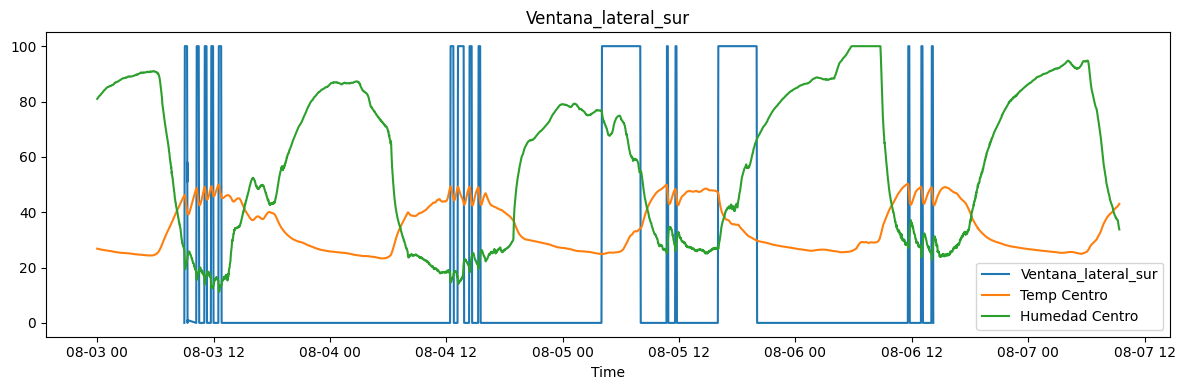

In [8]:
import matplotlib.pyplot as plt

for device in devicesVariables:
    print(f'Plotting {device} data...')
    try:
        device_data = pd.read_csv(f'climate devices experiments data/{device}_0.csv')
    except EmptyDataError as e:
        print(f"No data for device {device}: {e}")
        continue

    device_data['_time'] = pd.to_datetime(device_data['_time'], format='mixed', utc=True)
    # remove the timezone information from the _time column
    device_data['_time'] = device_data['_time'].dt.tz_localize(None)
    device_data['_time'] = device_data['_time'].dt.strftime('%Y-%m-%d %H:%M:%S')
    device_data['_time'] = pd.to_datetime(device_data['_time'])
    device_data['_value'] = device_data['_value'].clip(lower=0)  # set negative values to 0

    if device_data['_value'].max() == 1:
        device_data['_value'] = device_data['_value'] * 100  # convert to percentage

    # drop duplicated rows based on the _time column
    device_data = device_data.drop_duplicates(subset=['_time'])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(device_data['_time'], device_data['_value'], label=device)
    ax.plot(temp_centro['_time'], temp_centro['_value'], label='Temp Centro')
    ax.plot(humedad_centro['_time'], humedad_centro['_value'], label='Humedad Centro')
    ax.set_title(device)
    ax.set_xlabel('Time')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Verificación de la Fase B (dosis-respuesta, días 6-12)

Comprobamos si el barrido de niveles de la Fase B (un sistema climático a la vez,
varios niveles, cada uno x réplicas repartidas a lo largo de la campaña — ver
`REGLAS_EXPERIMENTO.pdf`, apartado 5) se ha ejecutado como estaba planeado.

**Cómo se verifica, sin fechas/horas fijadas a mano donde es posible:**

1. Reconstruimos el *nivel* de cada uno de los 7 grupos (LIGHTS, FOG, VENT_ROOF,
   VENT_SIDE, SHADE, RECIRC, RECIRC2) a resolución de 1 minuto a partir de los
   canales físicos correspondientes.
2. Detectamos automáticamente los tramos ("plateaus") en los que cada grupo se
   mantiene estable en un nivel, ignorando el ruido de los motores de ventanas
   mientras se mueven de una posición a otra.
3. Separamos los tramos que son en realidad la **regla de seguridad por
   sobretemperatura** (ventanas al 100 % cuando T > 45 °C) de los tramos que son
   de verdad parte del protocolo de dosis-respuesta.
4. Comparamos la secuencia de niveles observada, en orden, con la secuencia
   aleatorizada documentada en el PDF para cada dispositivo.
5. Representamos cada dispositivo junto con la temperatura/humedad interior para
   una inspección visual.

**Ventana temporal de la Fase B**: la campaña empezó el 2026-08-03 (Fase A,
días 1-5). Fase B arranca justo después del último ensayo de la Fase A (LIGHTS,
que se ve en los datos que corrió realmente 2026-08-07 16:00-20:00, no a las
18:00 como decía el documento). El final de la Fase B se detecta automáticamente
más abajo: es el primer momento en el que 2 o más de los 5 grupos con barrido
están encendidos a la vez de forma sostenida (huella característica del
factorial de la Fase C).

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import difflib

DATA_DIR = 'climate devices experiments data'

def _load_actuator_raw(filename):
    """Load one raw actuator/sensor CSV as a de-duplicated, sorted, non-negative
    pandas Series indexed by timestamp (values are event-based, not regular)."""
    d = pd.read_csv(f'{DATA_DIR}/{filename}')
    d['_time'] = pd.to_datetime(d['_time'], format='mixed', utc=True).dt.tz_localize(None)
    d = d.drop_duplicates(subset=['_time']).sort_values('_time')
    d['_value'] = d['_value'].clip(lower=0)
    return d.set_index('_time')['_value']

def _to_minute_grid(series, start, end):
    """Forward-fill an event-based actuator series onto a regular 1-min grid
    (actuator readings hold their last value until the next logged change)."""
    idx = pd.date_range(start, end, freq='1min')
    s = series.reindex(series.index.union(idx)).sort_index().ffill().reindex(idx)
    return s.fillna(0)

def build_group_levels(start, end):
    """Reconstruct the 7 PDF groups (section 2 of REGLAS_EXPERIMENTO.pdf) at
    1-min resolution over [start, end]."""
    vr_e = _to_minute_grid(_load_actuator_raw('Ventana_cenital_este_0.csv'), start, end)
    vr_o = _to_minute_grid(_load_actuator_raw('Ventana_cenital_oeste_0.csv'), start, end)
    vent_roof = (vr_e + vr_o) / 2

    vs_n = _to_minute_grid(_load_actuator_raw('Ventana_lateral_norte_0.csv'), start, end)
    vs_s = _to_minute_grid(_load_actuator_raw('Ventana_lateral_sur_0.csv'), start, end)
    vs_o = _to_minute_grid(_load_actuator_raw('Ventana_lateral_oeste_0.csv'), start, end)
    vent_side = (vs_n + vs_s + vs_o) / 3

    shade = _to_minute_grid(_load_actuator_raw('Pantalla_de_sombreo_cenital_0.csv'), start, end)

    # FOG is logged as raw 0/1 pulses (on/off), not as a pre-computed duty cycle.
    # Its documented "level" IS the duty cycle (% of each minute on), so we
    # resample the pulses at 1s resolution first and then average per minute.
    fog_raw = _load_actuator_raw('Fog_0.csv')
    fog_1s = fog_raw.reindex(pd.date_range(start, end, freq='1s')).ffill().fillna(0)
    fog_duty_pct = fog_1s.resample('1min').mean() * 100
    fog_duty_pct = fog_duty_pct.reindex(pd.date_range(start, end, freq='1min')).fillna(0)

    recirc = _to_minute_grid(_load_actuator_raw('Recirculador_0.csv'), start, end)

    heater0 = _to_minute_grid(_load_actuator_raw('Calefactores_0.csv'), start, end)
    heater2 = _to_minute_grid(_load_actuator_raw('Calefactores_2.csv'), start, end)
    recirc2 = (heater0 + heater2) / 2

    lights_channels = [_to_minute_grid(_load_actuator_raw(f'Luz_artificial_{c}_0.csv'), start, end)
                        for c in ['centro-este', 'centro-oeste', 'nor-este', 'nor-oeste', 'sur-este', 'sur-oeste']]
    lights = sum(lights_channels) / len(lights_channels)

    return pd.DataFrame({
        'VENT_ROOF': vent_roof,
        'VENT_SIDE': vent_side,
        'SHADE': shade,
        'FOG_duty_pct': fog_duty_pct,
        'LIGHTS': lights,
        'RECIRC': recirc,
        'RECIRC2': recirc2,
    })


def find_phase_c_start(levels, sweep_groups, min_run_minutes=60, active_threshold=1.0):
    """The Fase C factorial turns several dosis-response groups on *at once*;
    Fase B only ever runs one at a time. Return the first timestamp where
    >=2 of `sweep_groups` are simultaneously active for >= min_run_minutes."""
    active_count = (levels[sweep_groups] > active_threshold).sum(axis=1)
    is_multi = (active_count >= 2)
    run_id = (is_multi != is_multi.shift()).cumsum()
    for _, g in levels.groupby(run_id):
        if is_multi.loc[g.index[0]] and len(g) >= min_run_minutes:
            return g.index[0]
    return None


# Fase A's last trial (A11, LIGHTS) is visible in the data ending ~2026-08-07 20:00
# (it actually ran 16:00-20:00, two hours earlier than the planned 18:00-22:00 --
# see the timing note printed below). Fase B begins right after.
PHASE_B_START = pd.Timestamp('2026-08-07 20:30:00')
SEARCH_END = temp_centro['_time'].max()  # last timestamp available in the data

levels_full = build_group_levels(PHASE_B_START, SEARCH_END)
SWEEP_GROUPS = ['VENT_ROOF', 'VENT_SIDE', 'SHADE', 'FOG_duty_pct', 'LIGHTS']

phase_c_start = find_phase_c_start(levels_full, SWEEP_GROUPS)
PHASE_B_END = phase_c_start if phase_c_start is not None else levels_full.index[-1]

print(f"Fase B: {PHASE_B_START}  ->  {PHASE_B_END}")
print(f"(Fase C detectada a partir de: {phase_c_start} -- primer bloque con >=2 "
      f"sistemas encendidos a la vez durante >=60 min seguidos)")

levels_b = levels_full.loc[PHASE_B_START:PHASE_B_END]

Fase B: 2026-08-07 20:30:00  ->  2026-08-15 22:00:00
(Fase C detectada a partir de: 2026-08-15 22:00:00 -- primer bloque con >=2 sistemas encendidos a la vez durante >=60 min seguidos)


### Secuencias aleatorizadas documentadas (Fase B, apartado 5 del PDF)

Cada dispositivo se prueba solo, con el resto apagado. Insertamos un "off" (0)
entre cada dosis consecutiva porque cada bloque de tratamiento va seguido de
1 h de lavado a todo apagado (apartado 3): así la secuencia esperada, una vez
fusionados los ceros consecutivos, es directamente comparable con lo observado.

In [10]:
LEVELS = {
    'VENT_ROOF':    [0, 25, 50, 75, 100],
    'VENT_SIDE':    [0, 50, 100],
    'SHADE':        [0, 50, 100],
    'FOG_duty_pct': [0, 8.3, 16.7, 33.3],   # off / 5s / 10s / 20s por minuto
    'LIGHTS':       [0, 2, 5, 8, 10],
}
FOG_LABELS = {0: 'off', 8.3: '5s', 16.7: '10s', 33.3: '20s'}

DOCUMENTED_ORDER = {
    'VENT_ROOF':    [25, 0, 50, 100, 75, 75, 50, 25, 0, 100, 50, 75, 0, 100, 25],
    'VENT_SIDE':    [100, 50, 0, 50, 100, 0, 0, 100, 50],
    'SHADE':        [50, 100, 0, 50, 100, 0, 0, 50, 100],
    'FOG_duty_pct': [0, 33.3, 8.3, 16.7, 33.3, 16.7, 0, 8.3, 33.3, 8.3, 0, 16.7],
    'LIGHTS':       [0, 5, 8, 2, 10, 0, 10, 8, 5, 2, 0, 5, 2, 8, 10],
}

def expected_dose_sequence(doc_order):
    flat = []
    for dose in doc_order:
        flat += [dose, 0]              # each dose is followed by its washout (=0)
    collapsed = [flat[0]]
    for x in flat[1:]:
        if x != collapsed[-1]:
            collapsed.append(x)
    return [x for x in collapsed if x != 0]


def nearest_documented_level(x, levels):
    return min(levels, key=lambda l: abs(l - x))


def extract_stable_blocks(series, levels, min_block_minutes=8):
    """Run-length-encode a noisy actuator trace into stable blocks.

    A new block starts whenever the value jumps by more than half the smallest
    gap between two documented levels (this ignores the few minutes a window
    motor spends physically travelling between positions, while still catching
    every real level change). Blocks shorter than `min_block_minutes` are
    transition artefacts and are dropped; the surviving blocks are snapped to
    the nearest documented level and consecutive duplicates are merged.
    """
    gaps = np.diff(sorted(levels))
    step_threshold = min(4.0, max(1.0, gaps.min() / 2))

    v = series.values
    idx = series.index
    jumps = np.abs(np.diff(v, prepend=v[0])) > step_threshold
    raw_blocks = []
    start = 0
    for i in range(1, len(v) + 1):
        if i == len(v) or jumps[i]:
            raw_blocks.append((float(np.median(v[start:i])), idx[start], idx[i - 1], i - start))
            start = i

    kept = [b for b in raw_blocks if b[3] >= min_block_minutes]
    snapped = [(nearest_documented_level(lvl, levels), t0, t1, n) for lvl, t0, t1, n in kept]

    merged = []
    for lvl, t0, t1, n in snapped:
        if merged and merged[-1]['level'] == lvl:
            merged[-1]['end'] = t1
            merged[-1]['duration_min'] = merged[-1]['duration_min'] + n
        else:
            merged.append({'level': lvl, 'start': t0, 'end': t1, 'duration_min': n})
    return merged


def flag_safety_overrides(blocks, group, temp_series, safety_temp=44.0, max_safety_duration=90):
    """The only safety rule that injects a *nonzero* level into a group we sweep
    in Fase B is 'sobretemperatura -> ventanas 100%'. Mark short 100%-blocks in
    VENT_ROOF/VENT_SIDE that coincide with T > safety_temp as safety overrides,
    not as part of the randomized protocol, then fold them back out of the
    block list (as if the program had continued underneath)."""
    if group not in ('VENT_ROOF', 'VENT_SIDE'):
        return blocks, []
    kept, overrides = [], []
    for b in blocks:
        if b['level'] == 100 and b['duration_min'] < max_safety_duration:
            tmax = temp_series.loc[b['start']:b['end']].max()
            if pd.notna(tmax) and tmax > safety_temp:
                overrides.append(b)
                continue
        kept.append(b)
    # re-merge neighbours that are now adjacent after removing the override
    merged = []
    for b in kept:
        if merged and merged[-1]['level'] == b['level']:
            merged[-1]['end'] = b['end']
            merged[-1]['duration_min'] += b['duration_min']
        else:
            merged.append(dict(b))
    return merged, overrides

### Comparación dispositivo a dispositivo

In [11]:
verification = {}
for group, levels in LEVELS.items():
    blocks = extract_stable_blocks(levels_b[group], levels)
    blocks, safety_overrides = flag_safety_overrides(blocks, group, temp_centro.set_index('_time')['_value'])

    observed = [b['level'] for b in blocks if b['level'] != 0]
    expected = expected_dose_sequence(DOCUMENTED_ORDER[group])

    matcher = difflib.SequenceMatcher(a=expected, b=observed, autojunk=False)
    ratio = matcher.ratio()
    diffs = [op for op in matcher.get_opcodes() if op[0] != 'equal']

    short_blocks = [b for b in blocks if b['level'] != 0 and b['duration_min'] < 100]

    verification[group] = dict(blocks=blocks, safety_overrides=safety_overrides,
                                expected=expected, observed=observed,
                                ratio=ratio, diffs=diffs, short_blocks=short_blocks)

    label = lambda v: FOG_LABELS.get(v, v) if group == 'FOG_duty_pct' else v
    print(f"\n{'='*70}\n{group}\n{'='*70}")
    print(f"  Dosis esperadas ({len(expected)}): {[label(x) for x in expected]}")
    print(f"  Dosis observadas ({len(observed)}): {[label(x) for x in observed]}")
    print(f"  Coincidencia de secuencia: {ratio:.1%}")
    print(f"  Activaciones de la regla de seguridad (T>44°C) excluidas: {len(safety_overrides)}")
    if diffs:
        print("  Diferencias vs. lo documentado:")
        for tag, i1, i2, j1, j2 in diffs:
            if tag == 'delete':
                print(f"    -> falta(n) en los datos: {[label(x) for x in expected[i1:i2]]}"
                      f" (posición {i1+1} del orden documentado)")
            elif tag == 'insert':
                print(f"    -> de más en los datos (no documentado): {[label(x) for x in observed[j1:j2]]}"
                      f" (justo después de la posición {i1} del orden documentado)")
            elif tag == 'replace':
                print(f"    -> se esperaba {[label(x) for x in expected[i1:i2]]} y se observó "
                      f"{[label(x) for x in observed[j1:j2]]}")
    if short_blocks:
        print("  Bloques de tratamiento mas cortos de lo normal (~120 min esperados):")
        for b in short_blocks:
            print(f"    nivel={label(b['level'])}  inicio={b['start']}  duración={b['duration_min']} min")


VENT_ROOF
  Dosis esperadas (12): [25, 50, 100, 75, 75, 50, 25, 100, 50, 75, 100, 25]
  Dosis observadas (11): [25, 100, 75, 75, 50, 25, 100, 50, 75, 100, 25]
  Coincidencia de secuencia: 95.7%
  Activaciones de la regla de seguridad (T>44°C) excluidas: 20
  Diferencias vs. lo documentado:
    -> falta(n) en los datos: [50] (posición 2 del orden documentado)

VENT_SIDE
  Dosis esperadas (6): [100, 50, 50, 100, 100, 50]
  Dosis observadas (5): [100, 50, 50, 100, 100]
  Coincidencia de secuencia: 90.9%
  Activaciones de la regla de seguridad (T>44°C) excluidas: 20
  Diferencias vs. lo documentado:
    -> falta(n) en los datos: [50] (posición 6 del orden documentado)

SHADE
  Dosis esperadas (6): [50, 100, 50, 100, 50, 100]
  Dosis observadas (6): [50, 100, 50, 100, 50, 100]
  Coincidencia de secuencia: 100.0%
  Activaciones de la regla de seguridad (T>44°C) excluidas: 0

FOG_duty_pct
  Dosis esperadas (9): ['20s', '5s', '10s', '20s', '10s', '5s', '20s', '5s', '10s']
  Dosis observadas (

### Gráficas: nivel de cada dispositivo vs. temperatura/humedad interior

Línea de color = nivel real del dispositivo (eje izquierdo). Líneas grises =
temperatura y humedad del centro del invernadero (eje derecho), para ver si la
respuesta del clima tiene sentido físico. Las franjas rojas verticales marcan
activaciones de la regla de seguridad por sobretemperatura detectadas en ese
dispositivo.

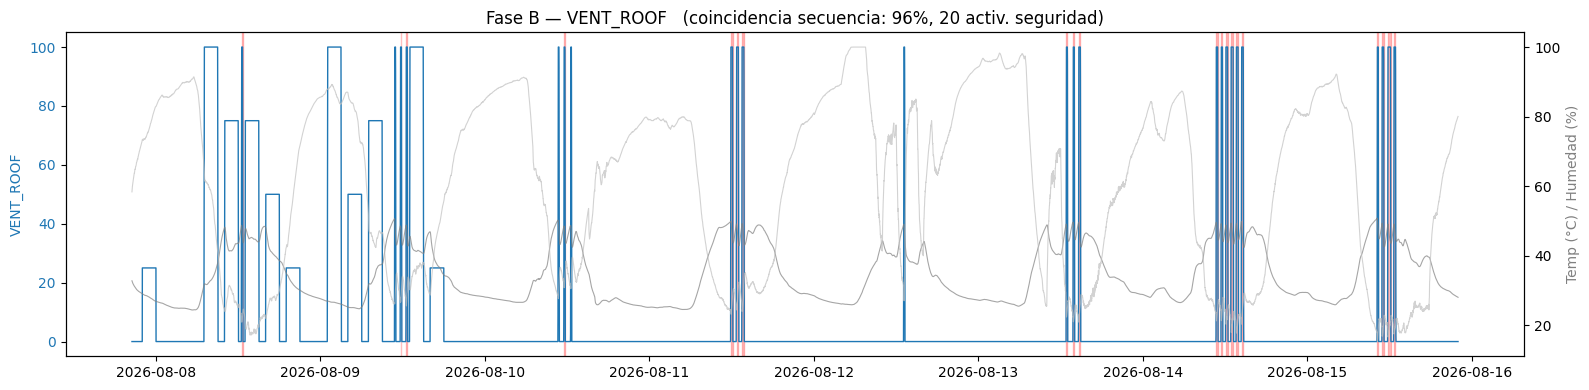

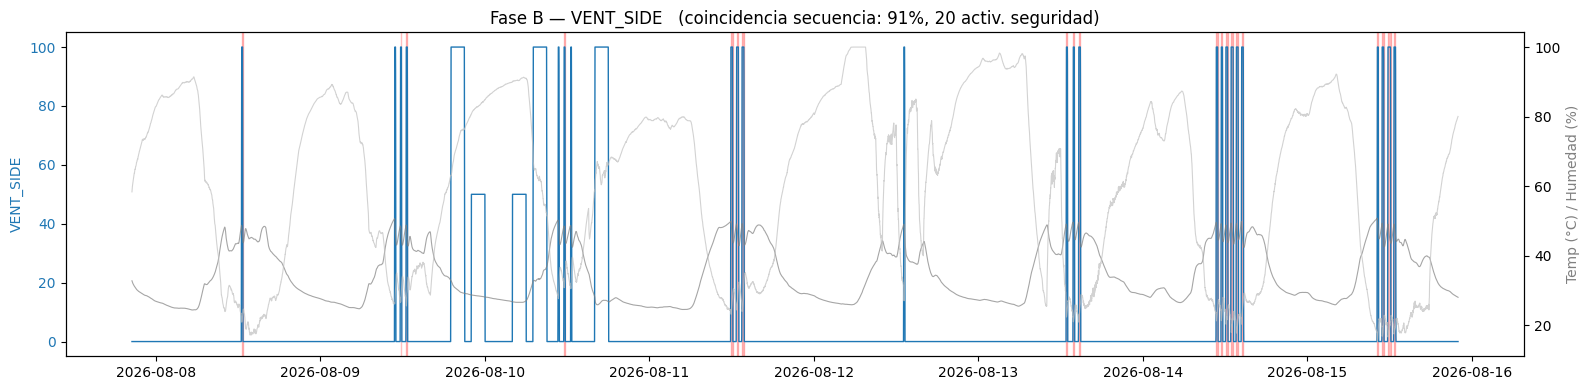

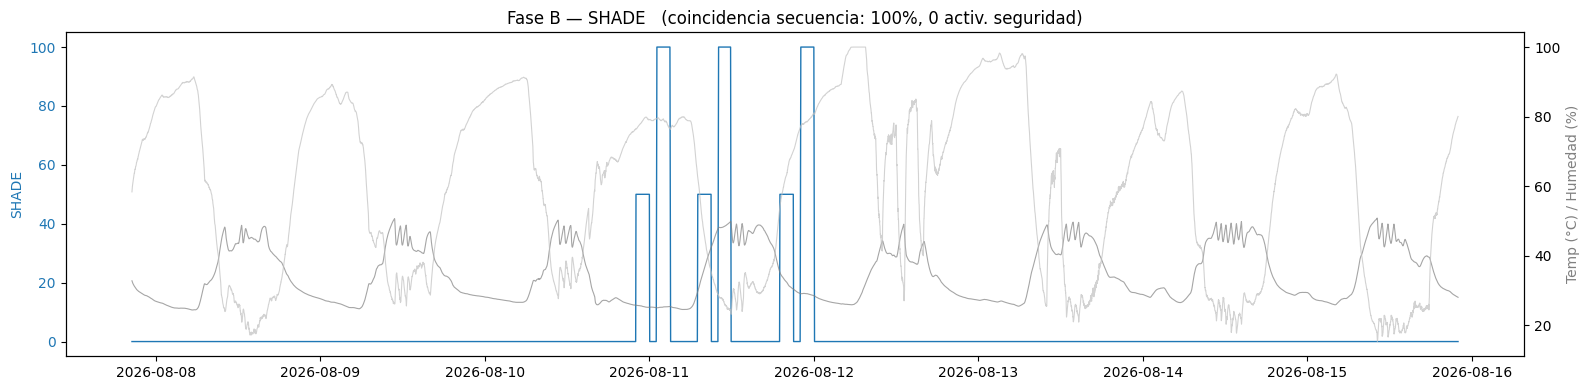

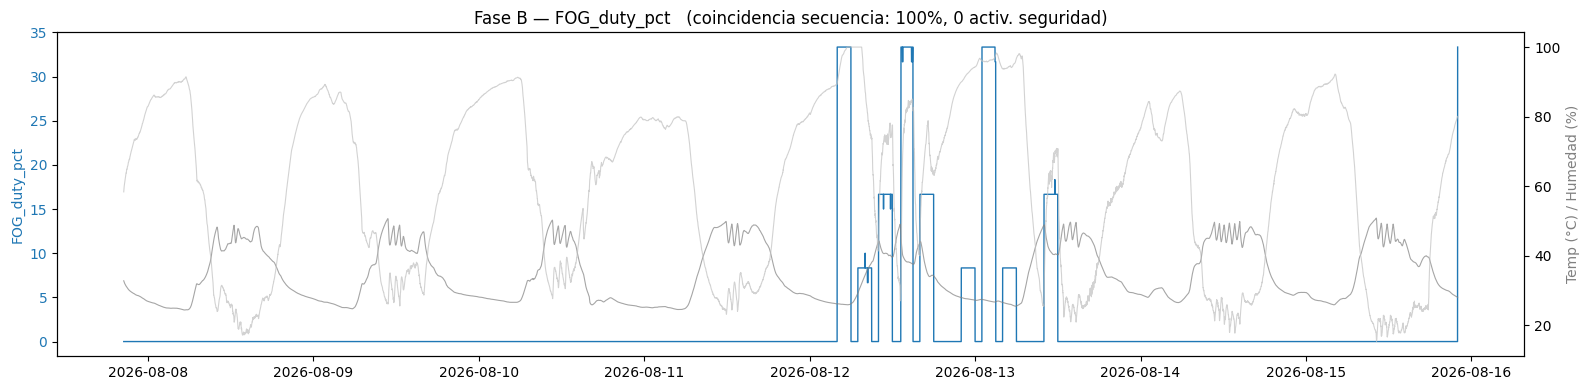

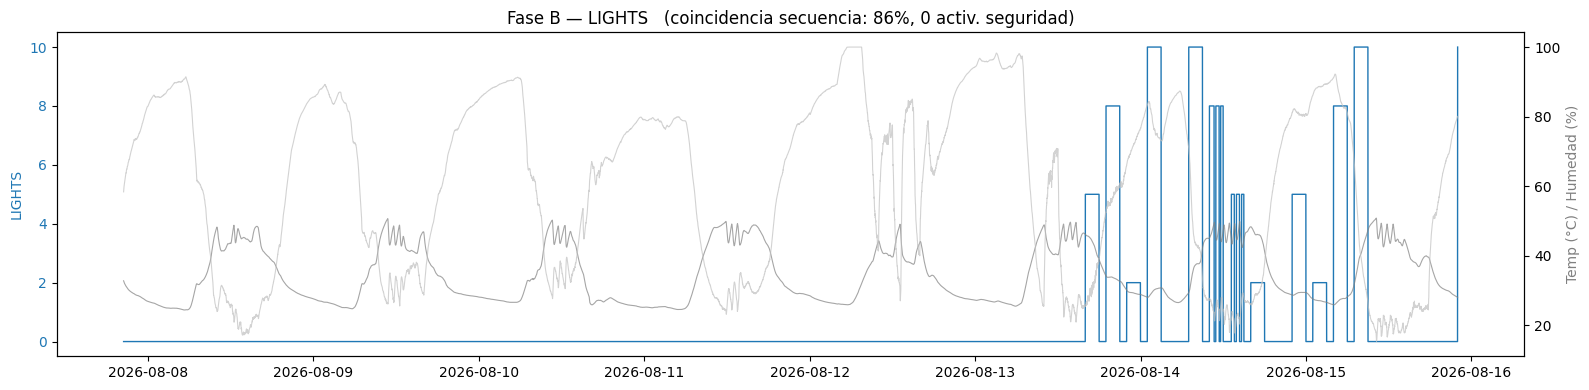

In [12]:
temp_c = temp_centro.set_index('_time')['_value']
hum_c = humedad_centro.set_index('_time')['_value']

for group in LEVELS:
    info = verification[group]
    fig, ax1 = plt.subplots(figsize=(16, 4))

    ax1.plot(levels_b.index, levels_b[group], color='tab:blue', lw=1, label=group)
    ax1.set_ylabel(group, color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    for b in info['safety_overrides']:
        ax1.axvspan(b['start'], b['end'], color='red', alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(temp_c.loc[levels_b.index[0]:levels_b.index[-1]].index,
              temp_c.loc[levels_b.index[0]:levels_b.index[-1]], color='gray', lw=0.8, alpha=0.7, label='Temp centro')
    ax2.plot(hum_c.loc[levels_b.index[0]:levels_b.index[-1]].index,
              hum_c.loc[levels_b.index[0]:levels_b.index[-1]], color='silver', lw=0.8, alpha=0.7, label='Humedad centro')
    ax2.set_ylabel('Temp (°C) / Humedad (%)', color='gray')

    ax1.set_title(f"Fase B — {group}   (coincidencia secuencia: {info['ratio']:.0%},"
                  f" {len(info['safety_overrides'])} activ. seguridad)")
    fig.tight_layout()
    plt.show()

### Resumen

- **SHADE** y **FOG**: barrido completo y en el orden correcto (100 % de
  coincidencia), con bloques de ~2 h como estaba previsto.
- **VENT_ROOF**: 11 de las 12 dosis se ven en el orden correcto; falta la dosis
  de **50 %** que debía ir entre el primer bloque (25 %, noche del 7-8 de
  agosto) y el bloque de 100 % de la madrugada del día 8 — revisar el hueco
  2026-08-08 00:00–07:00 en los logs del controlador.
- **VENT_SIDE**: 5 de las 6 dosis correctas; falta la **última dosis (50 %)**
  del barrido, que debía llegar tras el bloque de 100 % que terminó el
  2026-08-10 18:00 y nunca se aplicó.
- **LIGHTS**: el barrido se hizo de noche como recomienda el documento (nunca
  de día, salvo un episodio), y las 12 dosis documentadas aparecen todas en el
  orden correcto. Pero el 2026-08-14 entre las 10:00 y las 15:00 hay una
  activación diurna anómala: las luces se encienden y apagan en ráfagas cortas
  (20-40 min) a niveles 8 y 5 en vez de mantenerse fijas ~2 h -- esto no encaja
  con ningún bloque documentado y merece revisarse (¿prueba manual? ¿fallo del
  programador?).
- **Regla de seguridad por sobretemperatura**: saltó correctamente varias veces
  al mediodía en casi todos los días de la Fase B (T > ~44-50 °C en el
  invernadero vacío), abriendo las ventanas al 100 % durante 8-25 minutos antes
  de volver al programa. Esto confirma que la capa de seguridad funciona, pero
  también implica que los bloques de VENT_ROOF/VENT_SIDE que caen a mediodía
  pueden tener una interrupción breve de unos minutos.